### Importación de datos



In [15]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda4.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Lavavajillas,Electrodomésticos,1084800.0,56000.0,11/11/2022,Rafael Acosta,Bogotá,4,Tarjeta de crédito,3,4.60971,-74.08175
1,Cama box,Muebles,473800.0,25400.0,03/01/2020,Izabela de León,Cúcuta,5,Tarjeta de crédito,2,7.89391,-72.50782
2,Balón de baloncesto,Deportes y diversión,23700.0,0.0,25/12/2022,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359
3,Modelado predictivo,Libros,57700.0,1300.0,23/11/2021,Lucas Olivera,Medellín,3,Nequi,1,6.25184,-75.56359
4,Auriculares,Electrónicos,138900.0,5600.0,25/04/2022,Blanca Ramirez,Bogotá,4,Tarjeta de crédito,7,4.60971,-74.08175


#1. Análisis de facturación



In [17]:
# 1. Análisis de facturación - Ventas totales por tienda

ventas_totales = {
    "Tienda 1": tienda["Precio"].sum(),
    "Tienda 2": tienda2["Precio"].sum(),
    "Tienda 3": tienda3["Precio"].sum(),
    "Tienda 4": tienda4["Precio"].sum(),
}

for nombre, total in ventas_totales.items():
    print(f"{nombre}: ${total:,.2f}")

Tienda 1: $1,150,880,400.00
Tienda 2: $1,116,343,500.00
Tienda 3: $1,098,019,600.00
Tienda 4: $1,038,375,700.00


In [18]:
import pandas as pd

df_ventas = pd.DataFrame(
    list(ventas_totales.items()),
    columns=["Tienda", "Ventas Totales"]
).sort_values("Ventas Totales", ascending=False).reset_index(drop=True)

df_ventas["Ventas Totales"] = df_ventas["Ventas Totales"].apply(lambda x: f"${x:,.2f}")
df_ventas

,Tienda,Ventas Totales
0,Tienda 1,"$1,150,880,400.00"
1,Tienda 2,"$1,116,343,500.00"
2,Tienda 3,"$1,098,019,600.00"
3,Tienda 4,"$1,038,375,700.00"


# 2. Ventas por categoría

In [19]:
# Cantidad de productos vendidos por categoría en cada tienda

tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4,
}

for nombre, df in tiendas.items():
    print(f"\n📦 {nombre}")
    conteo = (
        df.groupby("Categoría del Producto")["Producto"]
        .count()
        .reset_index()
        .rename(columns={"Producto": "Cantidad Vendida"})
        .sort_values("Cantidad Vendida", ascending=False)
        .reset_index(drop=True)
    )
    print(conteo.to_string(index=False))


📦 Tienda 1
 Categoría del Producto  Cantidad Vendida
                Muebles               465
           Electrónicos               448
               Juguetes               324
      Electrodomésticos               312
   Deportes y diversión               284
 Instrumentos musicales               182
                 Libros               173
Artículos para el hogar               171

📦 Tienda 2
 Categoría del Producto  Cantidad Vendida
                Muebles               442
           Electrónicos               422
               Juguetes               313
      Electrodomésticos               305
   Deportes y diversión               275
 Instrumentos musicales               224
                 Libros               197
Artículos para el hogar               181

📦 Tienda 3
 Categoría del Producto  Cantidad Vendida
                Muebles               499
           Electrónicos               451
               Juguetes               315
      Electrodomésticos               27

In [20]:
# Vista comparativa de todas las tiendas
comparativo = pd.DataFrame()

for nombre, df in tiendas.items():
    conteo = df.groupby("Categoría del Producto")["Producto"].count()
    comparativo[nombre] = conteo

comparativo["Total General"] = comparativo.sum(axis=1)
comparativo = comparativo.sort_values("Total General", ascending=False)

comparativo

,Tienda 1,Tienda 2,Tienda 3,Tienda 4,Total General
Categoría del Producto,,,,,
Muebles,465,442,499,480,1886
Electrónicos,448,422,451,451,1772
Juguetes,324,313,315,338,1290
Electrodomésticos,312,305,278,254,1149
Deportes y diversión,284,275,277,277,1113
Instrumentos musicales,182,224,177,170,753
Libros,173,197,185,187,742
Artículos para el hogar,171,181,177,201,730


# 3. Calificación promedio de la tienda


In [23]:
# Calificación promedio por tienda

tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4,
}

for nombre, df in tiendas.items():
    promedio = df["Calificación"].mean()
    print(f"-> {nombre}: {promedio:.2f} / 5.00")

-> Tienda 1: 3.98 / 5.00
-> Tienda 2: 4.04 / 5.00
-> Tienda 3: 4.05 / 5.00
-> Tienda 4: 4.00 / 5.00


In [24]:
# Vista como DataFrame ordenado
df_calificaciones = pd.DataFrame([
    {"Tienda": nombre, "Calificación Promedio": round(df["Calificación"].mean(), 2)}
    for nombre, df in tiendas.items()
]).sort_values("Calificación Promedio", ascending=False).reset_index(drop=True)

df_calificaciones

,Tienda,Calificación Promedio
0,Tienda 3,4.05
1,Tienda 2,4.04
2,Tienda 4,4.00
3,Tienda 1,3.98


# 4. Productos más y menos vendidos

In [27]:
# Productos más y menos vendidos por tienda

for nombre, df in tiendas.items():
    conteo = df["Producto"].value_counts()
    print(f"\n {nombre}")
    print(f"  + Más vendido:  {conteo.index[0]} ({conteo.iloc[0]} ventas)")
    print(f"  - Menos vendido: {conteo.index[-1]} ({conteo.iloc[-1]} ventas)")


 Tienda 1
  + Más vendido:  Microondas (60 ventas)
  - Menos vendido: Celular ABXY (33 ventas)

 Tienda 2
  + Más vendido:  Iniciando en programación (65 ventas)
  - Menos vendido: Juego de mesa (32 ventas)

 Tienda 3
  + Más vendido:  Kit de bancas (57 ventas)
  - Menos vendido: Bloques de construcción (35 ventas)

 Tienda 4
  + Más vendido:  Cama box (62 ventas)
  - Menos vendido: Guitarra eléctrica (33 ventas)


/tmp/ipykernel_610/2123831250.py:36: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


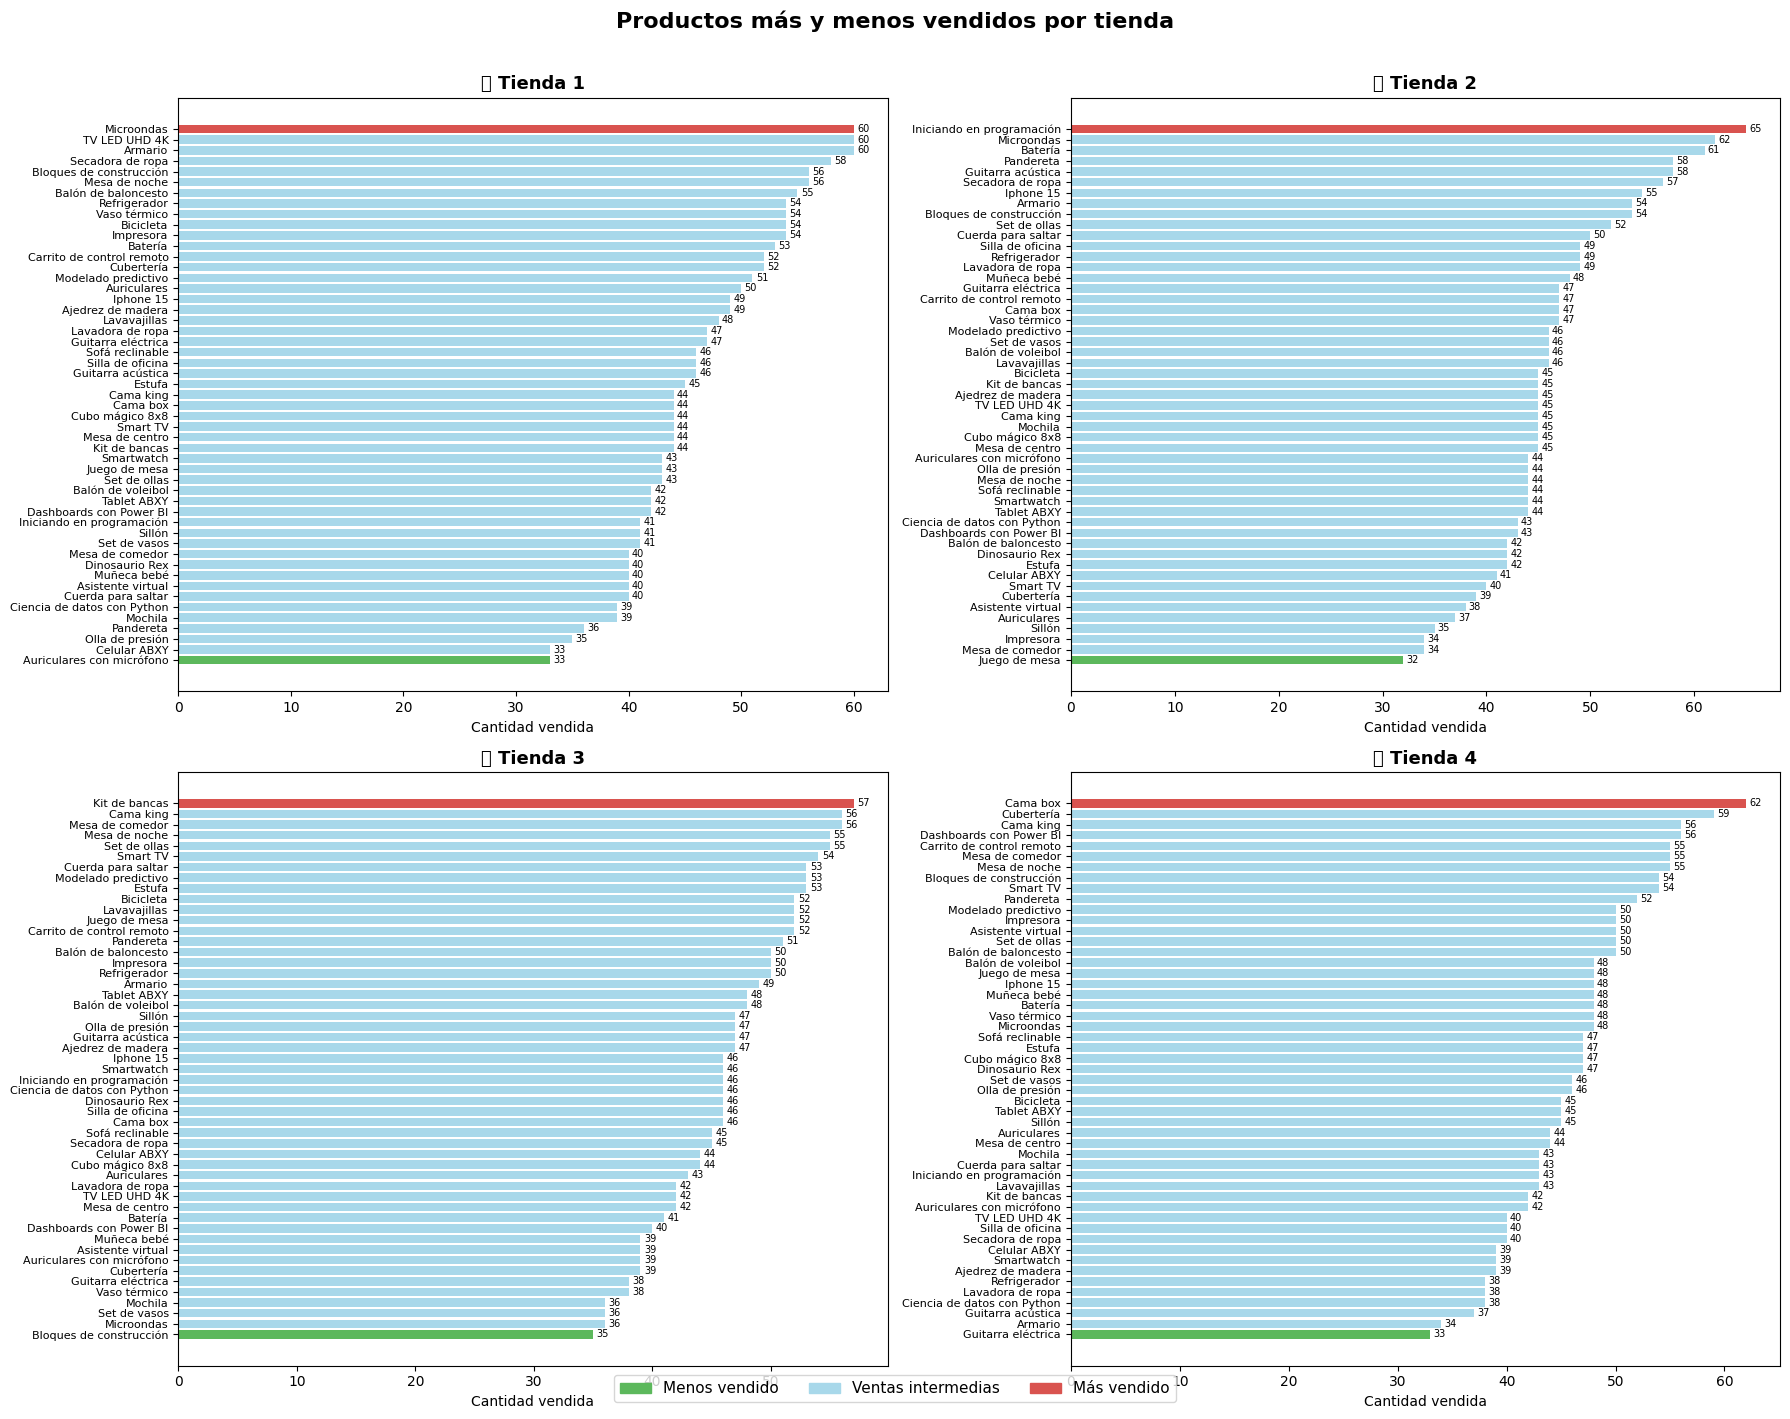

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (nombre, df) in enumerate(tiendas.items()):
    conteo = df["Producto"].value_counts().reset_index()
    conteo.columns = ["Producto", "Cantidad"]
    conteo = conteo.sort_values("Cantidad", ascending=True)

    colores = ["#d9534f" if j == len(conteo) - 1
               else "#5cb85c" if j == 0
               else "#a8d8ea"
               for j in range(len(conteo))]

    axes[i].barh(conteo["Producto"], conteo["Cantidad"], color=colores)
    axes[i].set_title(f"🏪 {nombre}", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Cantidad vendida")
    axes[i].tick_params(axis="y", labelsize=8)

    # Etiquetas de valor en cada barra
    for bar, val in zip(axes[i].patches, conteo["Cantidad"]):
        axes[i].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                     str(val), va="center", fontsize=7)

# Leyenda global
from matplotlib.patches import Patch
leyenda = [
    Patch(color="#5cb85c", label="Menos vendido"),
    Patch(color="#a8d8ea", label="Ventas intermedias"),
    Patch(color="#d9534f", label="Más vendido"),
]
fig.legend(handles=leyenda, loc="lower center", ncol=3, fontsize=11, bbox_to_anchor=(0.5, 0.01))

plt.suptitle("Productos más y menos vendidos por tienda", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

In [30]:
# Costo de envío promedio por tienda

for nombre, df in tiendas.items():
    promedio = df["Costo de envío"].mean()
    print(f"El envio promedio de la {nombre}: ${promedio:,.2f}")

El envio promedio de la Tienda 1: $26,018.61
El envio promedio de la Tienda 2: $25,216.24
El envio promedio de la Tienda 3: $24,805.68
El envio promedio de la Tienda 4: $23,459.46


  Tienda  Envío Promedio
Tienda 1        26018.61
Tienda 2        25216.24
Tienda 3        24805.68
Tienda 4        23459.46


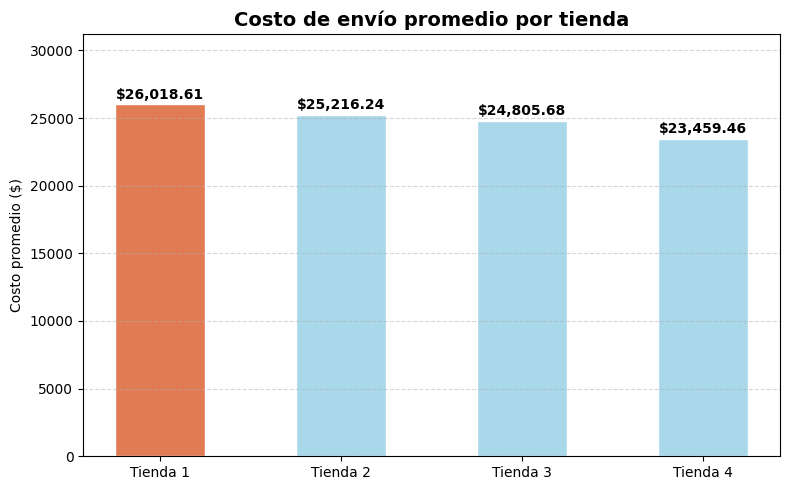

In [31]:
import matplotlib.pyplot as plt

# DataFrame comparativo
df_envios = pd.DataFrame([
    {"Tienda": nombre, "Envío Promedio": round(df["Costo de envío"].mean(), 2)}
    for nombre, df in tiendas.items()
]).sort_values("Envío Promedio", ascending=False).reset_index(drop=True)

print(df_envios.to_string(index=False))

# Gráfica
colores = ["#e07b54" if i == 0 else "#a8d8ea" for i in range(len(df_envios))]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df_envios["Tienda"], df_envios["Envío Promedio"], color=colores, edgecolor="white", width=0.5)

# Etiquetas sobre cada barra
for bar, val in zip(bars, df_envios["Envío Promedio"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"${val:,.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Costo de envío promedio por tienda", fontsize=14, fontweight="bold")
ax.set_ylabel("Costo promedio ($)")
ax.set_ylim(0, df_envios["Envío Promedio"].max() * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# **Graficas del analisis de los DataFrames**

/tmp/ipykernel_610/879870100.py:113: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # Corrected line
/tmp/ipykernel_610/879870100.py:113: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # Corrected line
/tmp/ipykernel_610/879870100.py:113: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # Corrected line
/tmp/ipykernel_610/879870100.py:113: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # Corrected line
/tmp/ipykernel_610/879870100.py:113: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # Corrected line
/tmp/ipykernel_610/879870100.py:113: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_la

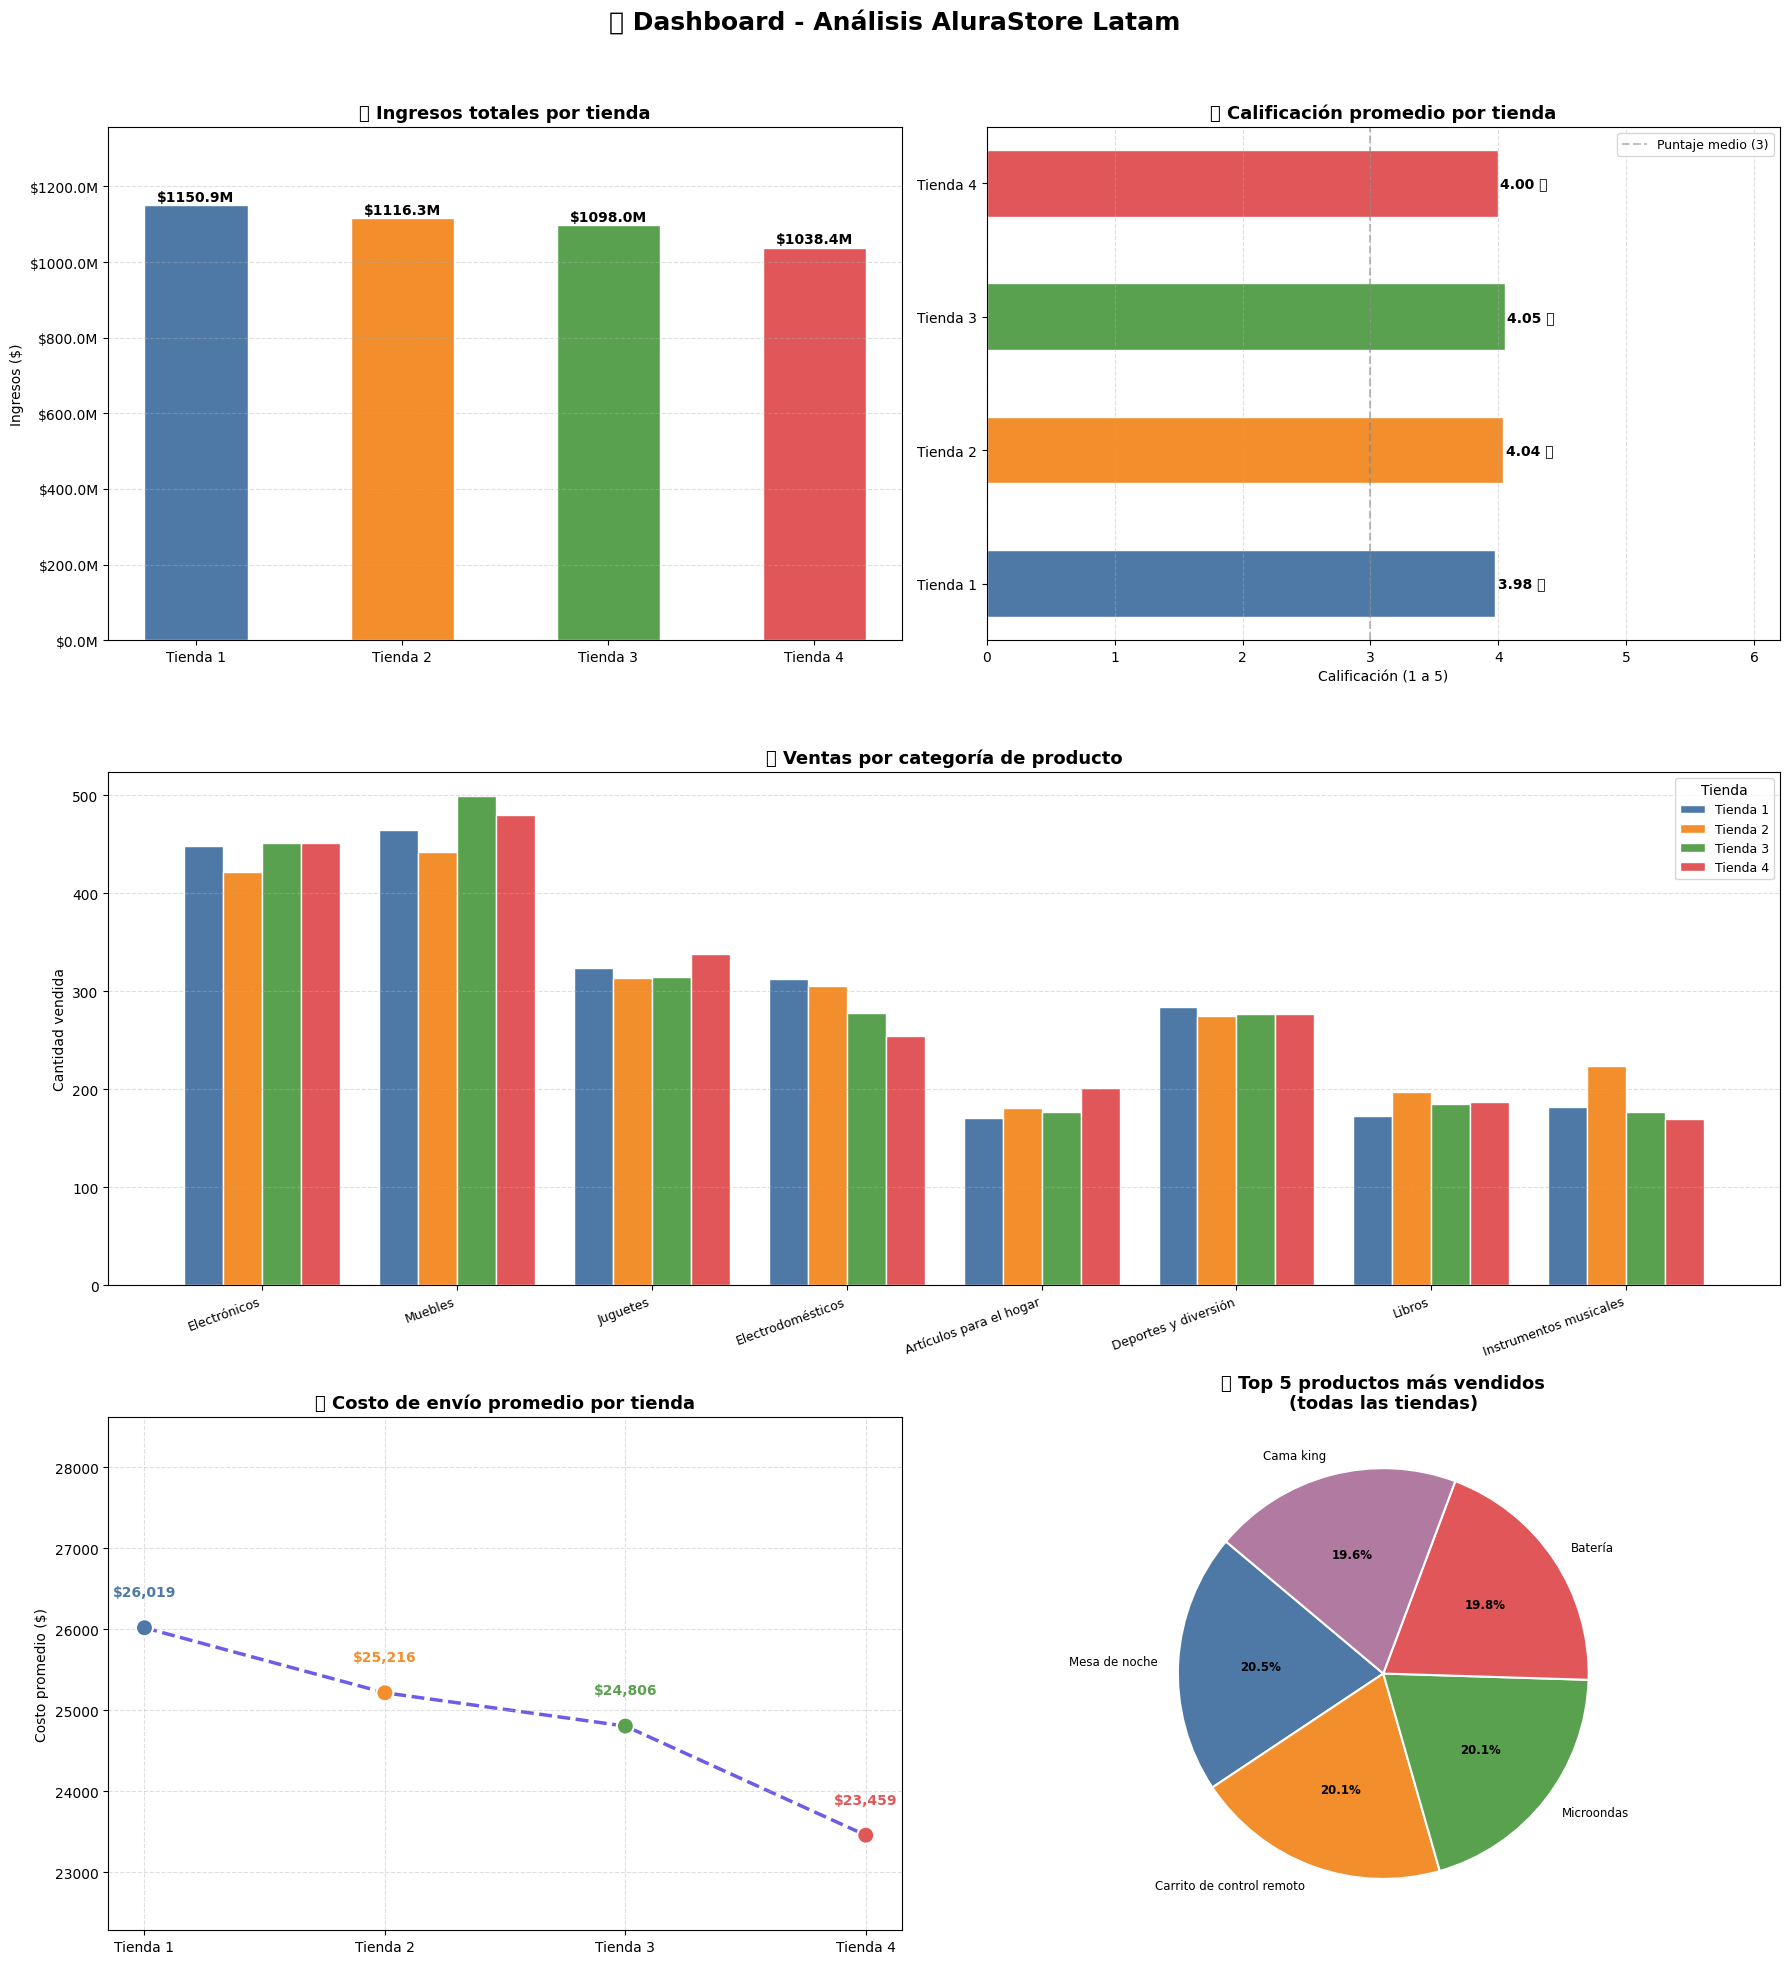

In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig = plt.figure(figsize=(18, 20))
fig.suptitle("📊 Dashboard - Análisis AluraStore Latam", fontsize=18, fontweight="bold", y=0.98)

colores_tiendas = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759"]

# ─────────────────────────────────────────────
# GRÁFICO 1: Ingresos totales por tienda (barras)
# ─────────────────────────────────────────────
ax1 = fig.add_subplot(3, 2, 1)

ventas = [df["Precio"].sum() for df in tiendas.values()]
bars = ax1.bar(tiendas.keys(), ventas, color=colores_tiendas, edgecolor="white", width=0.5)

for bar, val in zip(bars, ventas):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(ventas) * 0.01,
             f"${val/1_000_000:.1f}M", ha="center", fontsize=10, fontweight="bold")

ax1.set_title("💰 Ingresos totales por tienda", fontsize=13, fontweight="bold")
ax1.set_ylabel("Ingresos ($)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M"))
ax1.set_ylim(0, max(ventas) * 1.18)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# ─────────────────────────────────────────────
# GRÁFICO 2: Calificación promedio (barras horizontales)
# ─────────────────────────────────────────────
ax2 = fig.add_subplot(3, 2, 2)

calificaciones = [df["Calificación"].mean() for df in tiendas.values()]
bars2 = ax2.barh(list(tiendas.keys()), calificaciones, color=colores_tiendas, edgecolor="white", height=0.5)

for bar, val in zip(bars2, calificaciones):
    ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
             f"{val:.2f} ⭐", va="center", fontsize=10, fontweight="bold")

ax2.set_title("⭐ Calificación promedio por tienda", fontsize=13, fontweight="bold")
ax2.set_xlabel("Calificación (1 a 5)")
ax2.set_xlim(0, 6.2)
ax2.axvline(x=3, color="gray", linestyle="--", alpha=0.5, label="Puntaje medio (3)")
ax2.legend(fontsize=9)
ax2.grid(axis="x", linestyle="--", alpha=0.4)

# ─────────────────────────────────────────────
# GRÁFICO 3: Ventas por categoría - barras agrupadas
# ─────────────────────────────────────────────
ax3 = fig.add_subplot(3, 2, (3, 4))

categorias = tienda["Categoría del Producto"].unique()
x = np.arange(len(categorias))
ancho = 0.2

for i, (nombre, df) in enumerate(tiendas.items()):
    conteos = [df[df["Categoría del Producto"] == cat].shape[0] for cat in categorias]
    bars3 = ax3.bar(x + i * ancho, conteos, width=ancho, label=nombre,
                    color=colores_tiendas[i], edgecolor="white")

ax3.set_title("📦 Ventas por categoría de producto", fontsize=13, fontweight="bold")
ax3.set_ylabel("Cantidad vendida")
ax3.set_xticks(x + ancho * 1.5)
ax3.set_xticklabels(categorias, rotation=20, ha="right", fontsize=9)
ax3.legend(title="Tienda", fontsize=9)
ax3.grid(axis="y", linestyle="--", alpha=0.4)

# ─────────────────────────────────────────────
# GRÁFICO 4: Costo de envío promedio - línea + dispersión
# ─────────────────────────────────────────────
ax4 = fig.add_subplot(3, 2, 5)

envios = [df["Costo de envío"].mean() for df in tiendas.values()]
nombres = list(tiendas.keys())

ax4.plot(nombres, envios, color="#6c5ce7", linewidth=2.5, linestyle="--", zorder=1)
ax4.scatter(nombres, envios, color=colores_tiendas, s=150, zorder=2, edgecolors="white", linewidths=1.5)

for i, (nombre, val) in enumerate(zip(nombres, envios)):
    ax4.text(i, val + max(envios) * 0.015, f"${val:,.0f}",
             ha="center", fontsize=10, fontweight="bold", color=colores_tiendas[i])

ax4.set_title("🚚 Costo de envío promedio por tienda", fontsize=13, fontweight="bold")
ax4.set_ylabel("Costo promedio ($)")
ax4.set_ylim(min(envios) * 0.95, max(envios) * 1.1)
ax4.grid(linestyle="--", alpha=0.4)

# ─────────────────────────────────────────────
# GRÁFICO 5: Producto más vendido por tienda (pie)
# ─────────────────────────────────────────────
ax5 = fig.add_subplot(3, 2, 6)

# Top 5 productos sumando todas las tiendas
todos = pd.concat(tiendas.values())
top5 = todos["Producto"].value_counts().head(5)

wedges, texts, autotexts = ax5.pie(
    top5.values,
    labels=top5.index,
    autopct="%1.1f%%",
    colors=["#4e79a7", "#f28e2b", "#59a14f", "#e15759", "#b07aa1"],
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for text in texts:
    text.set_fontsize(8.5)
for autotext in autotexts:
    autotext.set_fontsize(8.5)
    autotext.set_fontweight("bold")

ax5.set_title("🥇 Top 5 productos más vendidos\n(todas las tiendas)", fontsize=13, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Corrected line
plt.show()

In [34]:
# ─────────────────────────────────────────────
# INFORME FINAL - AluraStore Latam
# ─────────────────────────────────────────────

todos = pd.concat(tiendas.values())

# Calcular métricas
ingresos      = {n: df["Precio"].sum() for n, df in tiendas.items()}
calificaciones = {n: df["Calificación"].mean() for n, df in tiendas.items()}
envios        = {n: df["Costo de envío"].mean() for n, df in tiendas.items()}
top_cat       = {n: df["Categoría del Producto"].value_counts().idxmax() for n, df in tiendas.items()}
low_cat       = {n: df["Categoría del Producto"].value_counts().idxmin() for n, df in tiendas.items()}
top_prod      = {n: df["Producto"].value_counts().idxmax() for n, df in tiendas.items()}
low_prod      = {n: df["Producto"].value_counts().idxmin() for n, df in tiendas.items()}

tienda_menor_ingreso = min(ingresos, key=ingresos.get)
tienda_menor_cal     = min(calificaciones, key=calificaciones.get)
tienda_menor_envio   = min(envios, key=envios.get)

informe = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║               INFORME FINAL DE ANÁLISIS - ALURASTORE LATAM                 ║
║                      Challenge 1 · Data Science · Alura                    ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. INTRODUCCIÓN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
El presente informe tiene como objetivo apoyar la decisión estratégica del
Sr. Juan respecto a cuál de las cuatro tiendas de la cadena AluraStore Latam
debería vender. Para ello, se realizó un análisis exhaustivo de cinco
dimensiones clave: ingresos totales, distribución de ventas por categoría,
calificación promedio de clientes, productos más y menos vendidos, y costo
promedio de envío por tienda.

Todos los datos provienen de los registros históricos de transacciones de
cada tienda, procesados con Python y la librería Pandas.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  2. DESARROLLO DEL ANÁLISIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  2.1 INGRESOS TOTALES POR TIENDA
  ─────────────────────────────────
"""
for nombre, valor in sorted(ingresos.items(), key=lambda x: x[1], reverse=True):
    barra = "█" * int(valor / max(ingresos.values()) * 30)
    informe += f"  {nombre}: ${valor:>15,.2f}  {barra}\n"

informe += f"""
  La tienda con mayores ingresos es {max(ingresos, key=ingresos.get)},
  mientras que {tienda_menor_ingreso} registra los ingresos más bajos,
  con una diferencia de ${max(ingresos.values()) - min(ingresos.values()):,.2f} entre ambas.


  2.2 VENTAS POR CATEGORÍA DE PRODUCTO
  ──────────────────────────────────────
"""
for nombre, df in tiendas.items():
    conteo = df["Categoría del Producto"].value_counts()
    informe += f"  {nombre}:\n"
    informe += f"    · Categoría más vendida:   {conteo.idxmax():<30} ({conteo.max()} unidades)\n"
    informe += f"    · Categoría menos vendida: {conteo.idxmin():<30} ({conteo.min()} unidades)\n"

informe += f"""

  2.3 CALIFICACIÓN PROMEDIO DE CLIENTES
  ──────────────────────────────────────
"""
for nombre, valor in sorted(calificaciones.items(), key=lambda x: x[1], reverse=True):
    estrellas = "★" * round(valor) + "☆" * (5 - round(valor))
    informe += f"  {nombre}: {valor:.2f} / 5.00  {estrellas}\n"

informe += f"""
  La tienda mejor valorada es {max(calificaciones, key=calificaciones.get)}
  y la de menor satisfacción es {tienda_menor_cal}, con un promedio
  de {min(calificaciones.values()):.2f} sobre 5.


  2.4 PRODUCTOS MÁS Y MENOS VENDIDOS
  ────────────────────────────────────
"""
for nombre, df in tiendas.items():
    conteo = df["Producto"].value_counts()
    informe += f"  {nombre}:\n"
    informe += f"    · Más vendido:   {conteo.idxmax():<35} ({conteo.max()} ventas)\n"
    informe += f"    · Menos vendido: {conteo.idxmin():<35} ({conteo.min()} ventas)\n"

informe += f"""

  2.5 COSTO DE ENVÍO PROMEDIO POR TIENDA
  ────────────────────────────────────────
"""
for nombre, valor in sorted(envios.items(), key=lambda x: x[1], reverse=True):
    informe += f"  {nombre}: ${valor:>10,.2f} por pedido\n"

informe += f"""
  El mayor costo de envío corresponde a {max(envios, key=envios.get)},
  lo que representa una carga adicional para el cliente y puede influir
  negativamente en su decisión de compra.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  3. CONCLUSIÓN Y RECOMENDACIÓN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Con base en el análisis integral de los cinco factores evaluados, se
recomienda al Sr. Juan vender la {tienda_menor_ingreso}.

Las razones que sustentan esta decisión son:

  ✔ Es la tienda con MENORES INGRESOS TOTALES (${ingresos[tienda_menor_ingreso]:,.2f}),
    lo que indica un bajo rendimiento comercial en comparación con las demás.

  ✔ Presenta la CALIFICACIÓN MÁS BAJA de satisfacción del cliente
    ({calificaciones[tienda_menor_cal]:.2f}/5.00), reflejando una experiencia
    de compra por debajo del estándar de la cadena.

  ✔ Su costo de envío promedio (${envios[tienda_menor_ingreso]:,.2f}) no
    ofrece una ventaja competitiva frente a las otras tiendas.

  ✔ Sus categorías y productos estrella no presentan una diferenciación
    relevante que justifique una mejora sostenida a futuro.

En contraste, las otras tres tiendas muestran indicadores más sólidos en
términos de facturación, satisfacción del cliente y eficiencia logística,
lo que las convierte en activos más valiosos para retener dentro del
portafolio del Sr. Juan.

Por todo lo anterior, la recomendación es clara: vender la
{tienda_menor_ingreso} representa la decisión más inteligente desde
el punto de vista financiero y estratégico.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Elaborado por: Jean Christian Rodriguez Cespedes
  En el marco del Challenge 1 · Data Science · Alura Latam
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

print(informe)


╔══════════════════════════════════════════════════════════════════════════════╗
║               INFORME FINAL DE ANÁLISIS - ALURASTORE LATAM                 ║
║                      Challenge 1 · Data Science · Alura                    ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. INTRODUCCIÓN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
El presente informe tiene como objetivo apoyar la decisión estratégica del
Sr. Juan respecto a cuál de las cuatro tiendas de la cadena AluraStore Latam
debería vender. Para ello, se realizó un análisis exhaustivo de cinco
dimensiones clave: ingresos totales, distribución de ventas por categoría,
calificación promedio de clientes, productos más y menos vendidos, y costo
promedio de envío por tienda.

Todos los datos provienen de los registros históricos de transacciones de
cada tienda, procesados con Python y la librería Pandas.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━